## Obtendo série temporais do ensemble

import os
import ee

In [252]:
import ee
import os
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import geemap
import matplotlib as mpl

In [5]:
project_id = 'ee-openetbrazil'

try:
    ee.Initialize(project=project_id)
except:
    ee.Authenticate()

In [115]:
# assets
ssebop_id = 'projects/ee-openetbrazil/assets/ssebop/landsat/v01'
ptjpl_id = 'projects/ee-openetbrazil/assets/ptjpl/landsat/v01'
sims_id = 'projects/ee-openetbrazil/assets/sims/landsat/v01'
etr_id = 'projects/ee-openetbrazil/assets/meteorological/daily/era5-land/sa'

In [119]:
def get_ensemble(image):
    
    # selecting bands
    image_rename=image.select([0,1,2])
    
    # date
    time_start = ee.Date(image.get('system:time_start'))

    # new image
    ensemble_img=image.reduce('mean').rename('ensemble_et')
    
    return image.addBands(ensemble_img).set('system:time_start',time_start.millis())

def get_etr(image):

    date = ee.Date(image.get('system:time_start'))

    # etr
    etr_img = ee.ImageCollection(etr_id).filterDate(date,date.advance(1,'day')).first()  

    return image.addBands(etr_img.set('system:time_start',date.millis()))


def get_region_df(info):
    """Convert the output of getRegions to a pandas dataframe"""
    col_dict = {}
    info_dict = {}
    for i, k in enumerate(info[0][4:]):
        col_dict[k] = i+4
        info_dict[k] = {}
        
    for row in info[1:]:
        date = datetime.datetime.utcfromtimestamp(row[3] / 1000.0).strftime('%Y-%m-%d')
        for k, v in col_dict.items():
            info_dict[k][date] = row[col_dict[k]]
            
    return pd.DataFrame.from_dict(info_dict).sort_index()

def get_df(table):

    CONVERSION = 1000
    
    # input lists
    list_date = []
    list_ssebop = []
    list_ptjpl = []
    list_sims = []
    list_ensemble = []
    list_etr = []

    # dataframe
    df = pd.DataFrame()

    for i, k in enumerate(table.getInfo()['features']):
        list_date.append(k['properties']['date'])
        list_ssebop.append(k['properties']['ssebop']/CONVERSION)
        list_ptjpl.append(k['properties']['ptjpl']/CONVERSION)
        list_sims.append(k['properties']['sims']/CONVERSION)
        list_ensemble.append(k['properties']['ensemble']/CONVERSION)
        list_etr.append(k['properties']['etr'])

    # saving
    df['date'] = pd.to_datetime(list_date)
    df['ssebop'] = list_ssebop
    df['ptjpl'] = list_ptjpl
    df['sims'] = list_sims
    df['ensemble'] = list_ensemble
    df['etr'] = list_etr

    df = df[df['ssebop']>0].reset_index().sort_values(by='date')

    return df

In [313]:
def merging_function(image):
    
    date = ee.Date(image.get('system:time_start'))

    # ssebop
    ssebop_img = ssebop_coll.filterDate(date,date.advance(1,'day')).first()
    ssebop_img = ee.ImageCollection.fromImages([ssebop_img.select("et"),ee.Image.constant(-9999)])\
                                   .reduce(ee.Reducer.firstNonNull())\
                                   .rename('et_ssebop')
    

    # ptjpl
    ptjpl_img = ptjpl_coll.filterDate(date,date.advance(1,'day')).first()
    
    ptjpl_img = ee.ImageCollection.fromImages([ptjpl_img.select("et"),ee.Image.constant(-9999)])\
                                   .reduce(ee.Reducer.firstNonNull())\
                                   .rename('et_ptjpl')
    # sims
    sims_img = ee.ImageCollection.fromImages([image.select("et"),ee.Image.constant(-9999)])\
                                   .reduce(ee.Reducer.firstNonNull())\
                                   .rename('et_ptjpl')
    return sims_img.addBands([ptjpl_img,ssebop_img])\
                     .set('system:time_start', date.millis())

# datas
start_date = ee.Date.fromYMD(2024,1,1)
end_date = ee.Date.fromYMD(2024,12,31)

# ponto de interesse
#lat = ex3 urucuia -13.2387 ex2 sao marcos -16.6014 #ex1 (sao marcos):-16.417
#lon = ex3 urucuia -45.91806 ex2 sao marcos -47.3235 #ex1 (sao marcos):-47.32
lat = -13.2387
lon = -45.91806
# geometria
geom = ee.Geometry.Point([lon, lat])

# filtering
ssebop_coll = ee.ImageCollection(ssebop_id).filterDate(start_date, end_date).filterBounds(geom)
ptjpl_coll = ee.ImageCollection(ptjpl_id).filterDate(start_date, end_date).filterBounds(geom)
sims_coll = ee.ImageCollection(sims_id).filterDate(start_date, end_date).filterBounds(geom)

print('Número de imagens coll SIMS:',ssebop_coll.aggregate_count('system:time_start').getInfo())
print('Número de imagens coll SIMS:',ptjpl_coll.aggregate_count('system:time_start').getInfo())
print('Número de imagens coll SIMS:',sims_coll.aggregate_count('system:time_start').getInfo())


# juntando as coleções e obtendo o ensemble
merge_colls = sims_coll.map(merging_function) #.map(get_ensemble)

# combine
combine = ssebop_coll.select('et').combine(ptjpl_coll.select('et')).combine(sims_coll.select('et'))

combine_ensemble = combine.map(get_ensemble).map(get_etr)

def get_table(image):

    date = ee.Date(image.get('system:time_start')).format('YYYY-MM-dd')

    red = image.reduceRegion(
        reducer = ee.Reducer.mean(),
        scale = 90,
        maxPixels = 10e12,
        geometry= geom
    )

    return ee.Feature(None,{'ssebop': ee.List([red.get('et'),-9999]).reduce(ee.Reducer.firstNonNull()),
                            'ptjpl': ee.List([red.get('et_1'),-9999]).reduce(ee.Reducer.firstNonNull()),
                            'sims':ee.List([red.get('et_2'),-9999]).reduce(ee.Reducer.firstNonNull()),
                            'ensemble':ee.List([red.get('ensemble_et'),-9999]).reduce(ee.Reducer.firstNonNull()),
                            'etr':ee.List([red.get('eto_asce'),-9999]).reduce(ee.Reducer.firstNonNull()),
                            'date':date})

# creating a feature collection
feature_collection = combine_ensemble.map(get_table)

# get DataFrame
df = get_df(feature_collection)

Número de imagens coll SIMS: 29
Número de imagens coll SIMS: 29
Número de imagens coll SIMS: 26


Text(0.5, 0, 'Data')

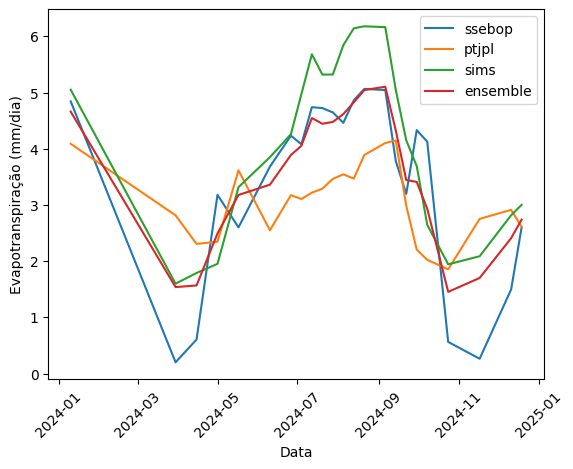

In [314]:
plt.plot(df['date'],df['ssebop'], label = 'ssebop')
plt.plot(df['date'],df['ptjpl'], label = 'ptjpl')
plt.plot(df['date'],df['sims'], label = 'sims')
plt.plot(df['date'],df['ensemble'], label = 'ensemble')

plt.legend()
plt.ylabel('Evapotranspiração (mm/dia)')
plt.xticks(rotation=45)
plt.xlabel('Data')

In [315]:
# era5 etr colleciton
etr_coll = ee.ImageCollection('projects/ee-openetbrazil/assets/meteorological/daily/era5-land/sa')

etr_period = etr_coll.filterDate('2024-01-01','2025-01-01')

df_etr = get_region_df(etr_period.getRegion(geom, scale=30).getInfo())
df_etr = df_etr.reset_index()

C:\Users\hge2022\AppData\Local\Temp\ipykernel_6760\2991209973.py:33: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  date = datetime.datetime.utcfromtimestamp(row[3] / 1000.0).strftime('%Y-%m-%d')


In [146]:
df_etr

,temperature_2m_max,temperature_2m_mean,temperature_2m_min,vapor_pressure,surface_solar_radiation_downwards,wind_2m,eto_asce,etr_asce
2024-01-01,27.552889,23.496914,19.440939,2.335390,17.114924,0.622237,3.557162,3.762307
2024-01-02,25.621351,22.655065,19.688779,2.331319,12.424648,0.993021,2.733545,2.968358
2024-01-03,23.411039,21.867118,20.323198,2.330733,6.880952,1.495062,1.641257,1.872524
2024-01-04,22.879855,21.416078,19.952300,2.345269,9.122840,1.638601,1.982665,2.151031
2024-01-05,23.656895,21.735729,19.814563,2.308664,10.566212,1.486813,2.326145,2.553279
...,...,...,...,...,...,...,...,...
2024-12-27,26.134412,22.769215,19.404018,2.279578,15.507932,0.797746,3.245496,3.470827
2024-12-28,27.277416,23.447495,19.617574,2.169923,19.812180,0.849247,4.076572,4.418118
2024-12-29,25.212391,22.266867,19.321343,2.170681,12.930428,0.946922,2.850422,3.130357
2024-12-30,24.089809,21.686647,19.283485,2.240252,9.854312,0.822982,2.230890,2.400256


In [316]:
import pandas as pd
import numpy as np

df['ensemble_etf'] = df['ensemble']/df['etr']
df = df.groupby('date').mean().reset_index()
df_interp = df.set_index('date')

new_index = pd.date_range(start='2024-01-01', end='2024-12-31', freq='D')
df_interp = df_interp[['ensemble_etf','ensemble']].reindex(new_index)

# 3. Interpolate & Extrapolate (repeat edge values)
# method='time' ensures linear scaling based on date difference
df_interp['ensemble_etf'] = df_interp['ensemble_etf'].interpolate(method='time').bfill().ffill()
df_interp = df_interp.reset_index()

df_interp['etr'] = df_etr['eto_asce']
df_interp['et_interp'] = df_etr['eto_asce']*df_interp['ensemble_etf']


Text(0.5, 0.98, 'Evapotranspiração Ensemble lat: -13.24 lon: -45.92')

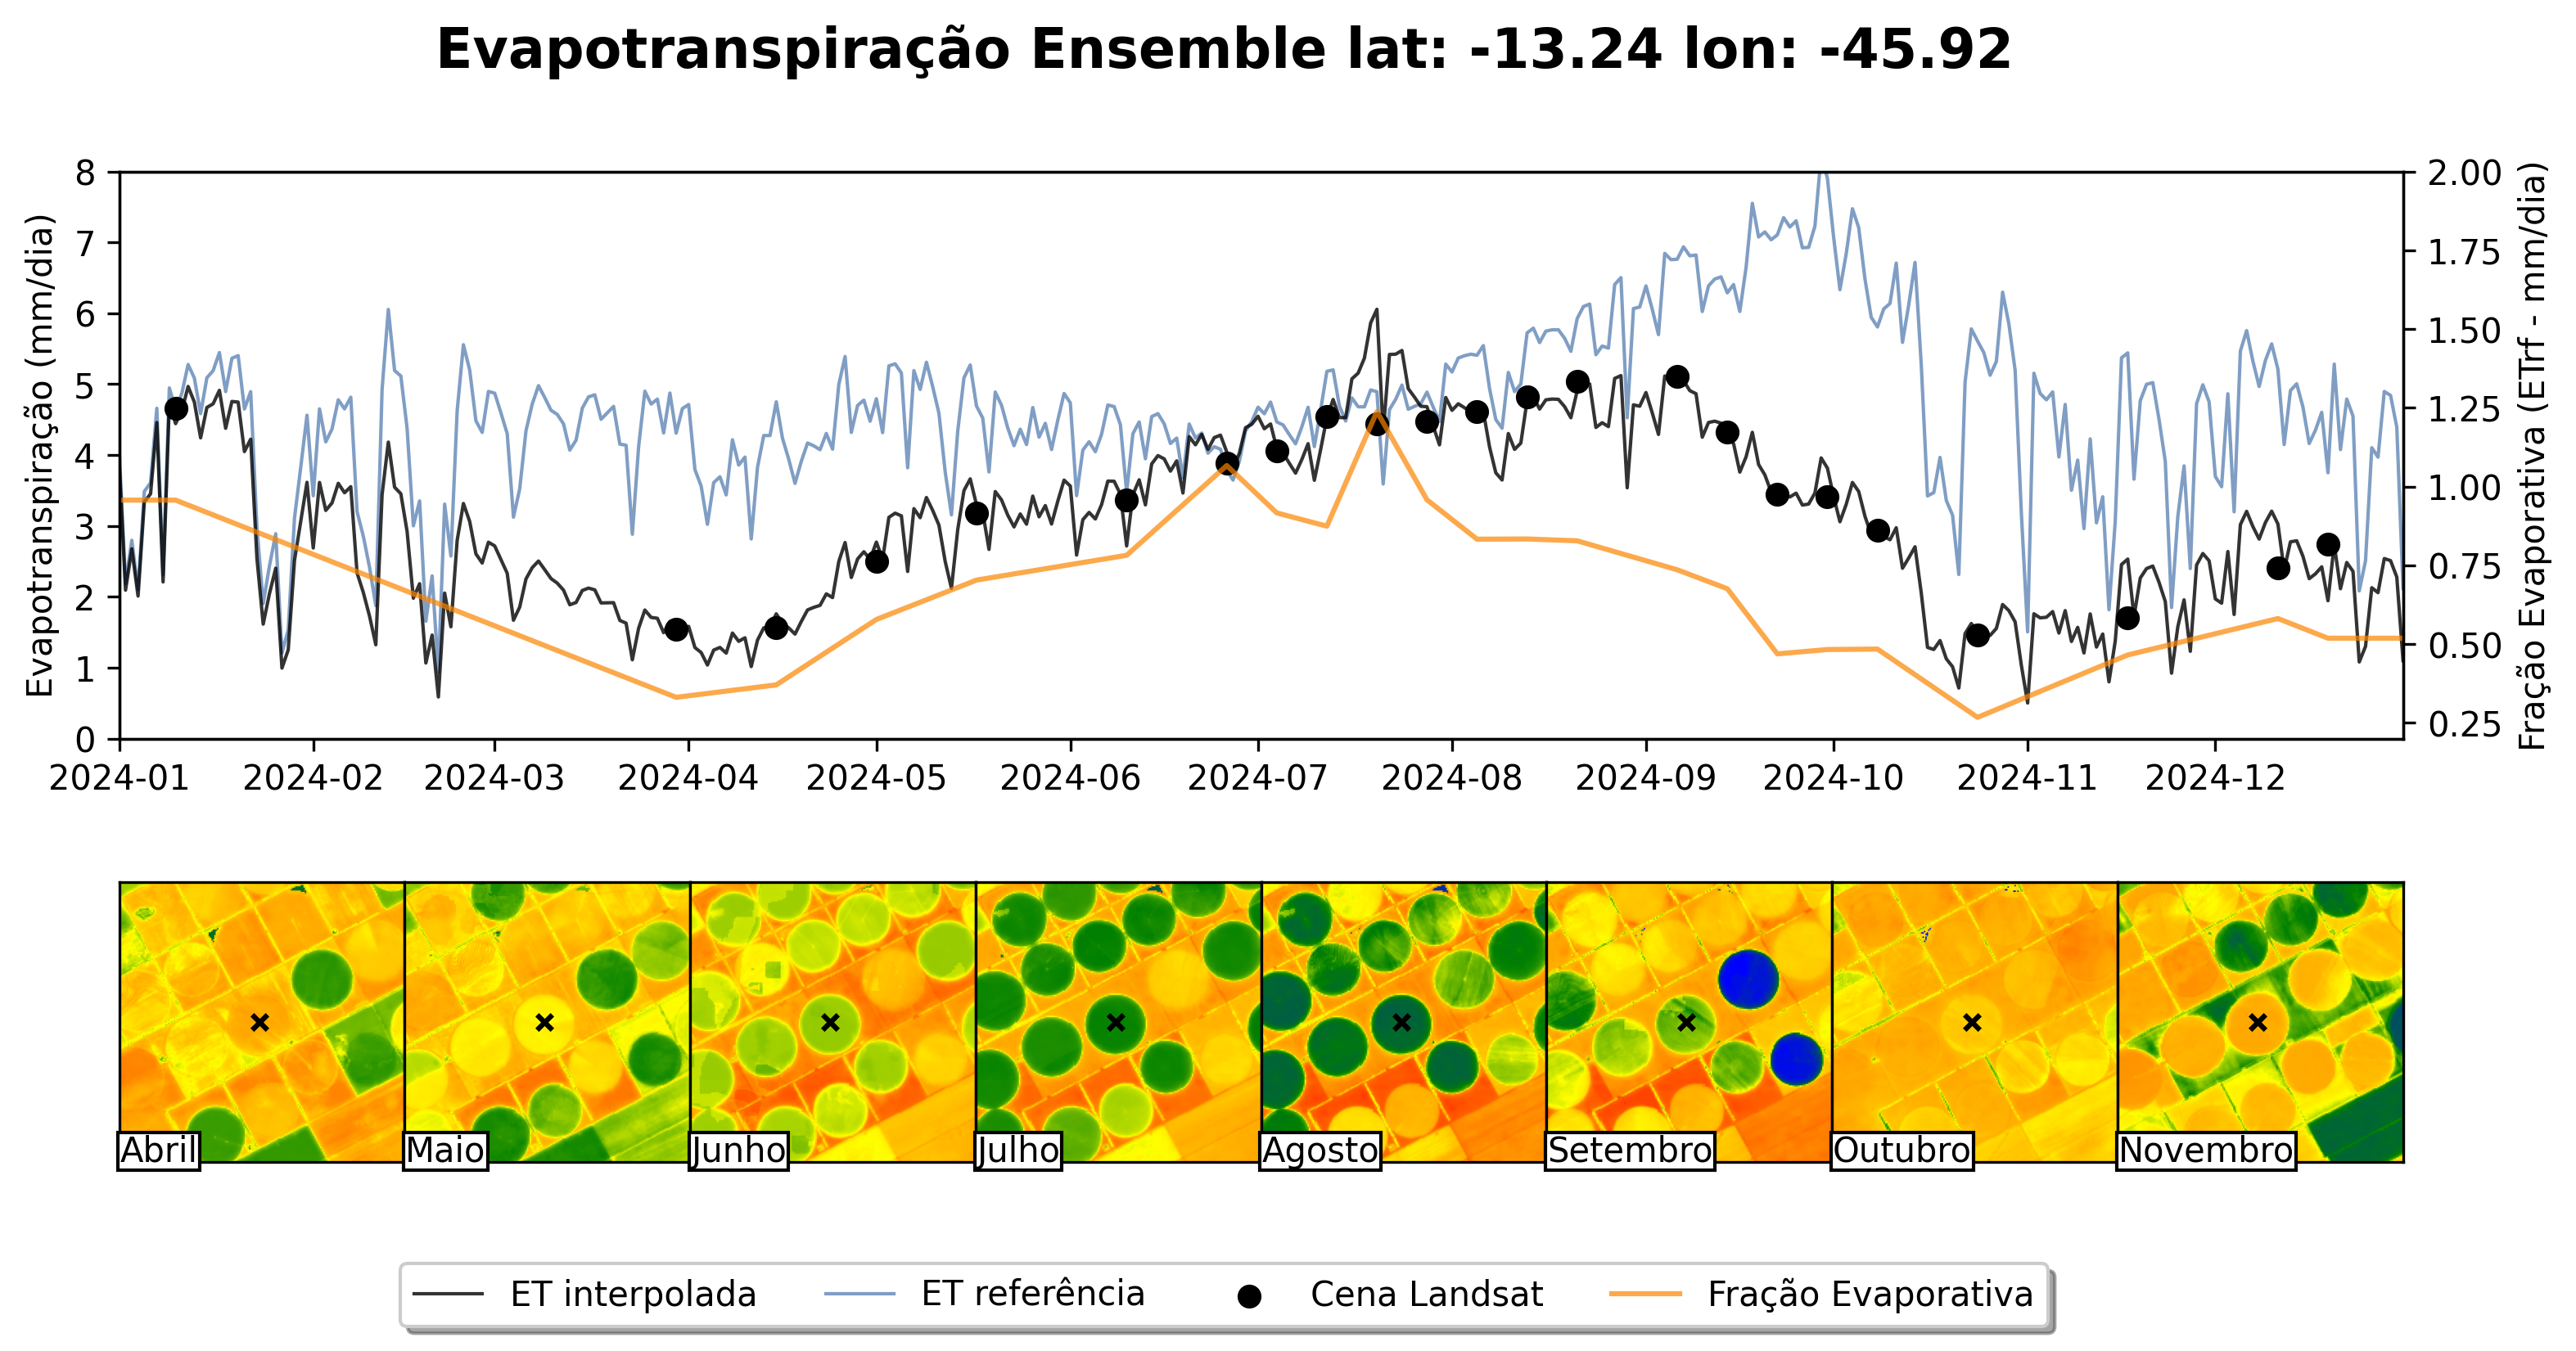

In [320]:
#fig, ax = plt.subplots(figsize=(12,6), dpi=300)


fig = plt.figure(figsize=(12,6), dpi=300)

plt.rcParams['figure.autolayout'] = False # Ensure tight_layout is off
plt.rcParams['figure.constrained_layout.use'] = False

ax = plt.subplot2grid((2, 8), (0, 0), colspan=8)

ax.plot(df_interp['index'],df_interp['et_interp'], color='black', alpha=0.8,lw=1, zorder=10, label = 'ET interpolada')
ax.plot(df_interp['index'],df_interp['etr'], color='#023e8a',alpha=0.5, lw=1, zorder=1, label= 'ET referência')
ax.scatter(df_interp['index'],df_interp['ensemble'], color='black', zorder=9, label='Cena Landsat')
ax.set_ylim(0,8)
ax.set_ylabel('Evapotranspiração (mm/dia)')


ax2 = ax.twinx()

ax2.plot(df_interp['index'],df_interp['ensemble_etf'], color='#fb8500',alpha=0.7, zorder=0, label= 'Fração Evaporativa')
ax2.set_ylim(0.2,2)
ax2.set_xlim(datetime.datetime(2024,1,1),datetime.datetime(2024,12,31))
ax2.set_ylabel('Fração Evaporativa (ETrf - mm/dia)', rotation=90)

# area plot
area_de_interesse = geom.buffer(3000).bounds()

#visualizando
vis_params = {
    'min': 0,
    'max': 6000 , # fator de escala: 1000
    'palette': ['red', 'orange', 'yellow', 'green', 'blue'] 
}


ax1 = plt.subplot2grid((2, 8), (1, 0))
img_jan = combine_ensemble.select('ensemble_et').filterDate('2024-04-01','2024-05-01').median()
rgb_vis = img_jan.visualize(**vis_params)
rgb_img = geemap.ee_to_numpy(rgb_vis, region=area_de_interesse, scale=30)
plt.imshow(rgb_img)
plt.xticks([])
plt.yticks([])
plt.scatter([100],[100], s=20, marker='x',color='k')
plt.text(0,200,'Abril',bbox=dict(facecolor='white', alpha=1, edgecolor='black', pad=0.50))

ax2 = plt.subplot2grid((2, 8), (1, 1))
img_jan = combine_ensemble.select('ensemble_et').filterDate('2024-05-01','2024-06-01').median()
rgb_vis = img_jan.visualize(**vis_params)
rgb_img = geemap.ee_to_numpy(rgb_vis, region=area_de_interesse, scale=30)
plt.imshow(rgb_img)
plt.xticks([])
plt.yticks([])
plt.scatter([100],[100], s=20, marker='x',color='k')
plt.text(0,200,'Maio',bbox=dict(facecolor='white', alpha=1, edgecolor='black', pad=0.50))

ax3 = plt.subplot2grid((2, 8), (1, 2))
img_jan = combine_ensemble.select('ensemble_et').filterDate('2024-06-01','2024-07-01').median()
rgb_vis = img_jan.visualize(**vis_params)
rgb_img = geemap.ee_to_numpy(rgb_vis, region=area_de_interesse, scale=30)
plt.imshow(rgb_img)
plt.xticks([])
plt.yticks([])
plt.scatter([100],[100], s=20, marker='x',color='k')
plt.text(0,200,'Junho',bbox=dict(facecolor='white', alpha=1, edgecolor='black', pad=0.50))

ax4 = plt.subplot2grid((2, 8), (1, 3))
img_jan = combine_ensemble.select('ensemble_et').filterDate('2024-07-01','2024-08-01').median()
rgb_vis = img_jan.visualize(**vis_params)
rgb_img = geemap.ee_to_numpy(rgb_vis, region=area_de_interesse, scale=30)
plt.imshow(rgb_img)
plt.xticks([])
plt.yticks([])
plt.scatter([100],[100], s=20, marker='x',color='k')
plt.text(0,200,'Julho',bbox=dict(facecolor='white', alpha=1, edgecolor='black', pad=0.50))

ax5 = plt.subplot2grid((2, 8), (1, 4))
img_jan = combine_ensemble.select('ensemble_et').filterDate('2024-08-01','2024-09-01').median()
rgb_vis = img_jan.visualize(**vis_params)
rgb_img = geemap.ee_to_numpy(rgb_vis, region=area_de_interesse, scale=30)
plt.imshow(rgb_img)
plt.xticks([])
plt.yticks([])
plt.scatter([100],[100], s=20, marker='x',color='k')
plt.text(0,200,'Agosto',bbox=dict(facecolor='white', alpha=1, edgecolor='black', pad=0.50))

ax6 = plt.subplot2grid((2, 8), (1, 5))
img_jan = combine_ensemble.select('ensemble_et').filterDate('2024-09-01','2024-10-01').median()
rgb_vis = img_jan.visualize(**vis_params)
rgb_img = geemap.ee_to_numpy(rgb_vis, region=area_de_interesse, scale=30)
plt.imshow(rgb_img)
plt.xticks([])
plt.yticks([])
plt.scatter([100],[100], s=20, marker='x',color='k')
plt.text(0,200,'Setembro',bbox=dict(facecolor='white', alpha=1, edgecolor='black', pad=0.50))

ax7 = plt.subplot2grid((2, 8), (1, 6))
ax7.set_aspect('equal')
img_jan = combine_ensemble.select('ensemble_et').filterDate('2024-10-01','2024-11-01').median()
rgb_vis = img_jan.visualize(**vis_params)
rgb_img = geemap.ee_to_numpy(rgb_vis, region=area_de_interesse, scale=30)
plt.imshow(rgb_img)
plt.xticks([])
plt.yticks([])
plt.scatter([100],[100], s=20, marker='x',color='k')
plt.text(0,200,'Outubro',bbox=dict(facecolor='white', alpha=1, edgecolor='black', pad=0.50))

ax8 = plt.subplot2grid((2, 8), (1, 7))
ax8.set_aspect('equal')
img_jan = combine_ensemble.select('ensemble_et').filterDate('2024-11-01','2024-12-01').median()
rgb_vis = img_jan.visualize(**vis_params)
rgb_img = geemap.ee_to_numpy(rgb_vis, region=area_de_interesse, scale=30)
plt.imshow(rgb_img)
plt.xticks([])
plt.yticks([])
plt.scatter([100],[100], s=20, marker='x',color='k')
plt.text(0,200,'Novembro',bbox=dict(facecolor='white', alpha=1, edgecolor='black', pad=0.50))

# 5. Add the Color Bar
# We create a manual mapping using the same min, max, and palette
cmap = mpl.colors.LinearSegmentedColormap.from_list("custom", ['red', 'orange', 'yellow', 'green', 'blue'] )
norm = mpl.colors.Normalize(vmin=0, vmax=6)

# Create a "ScalarMappable" for the color bar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) # Required for Matplotlib versions < 3.1


#cbar = fig.colorbar(sm, ax=ax,  shrink=0.90, aspect=20, orientation='vertical', fraction=0.046, pad=0.04)
#cbar.set_label('ET (mm/dia)')

fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.15),
          fancybox=True, shadow=True, ncol=5)

fig.subplots_adjust(hspace=0, wspace=0)

fig.suptitle(rf'Evapotranspiração Ensemble lat: {np.round(lat,2)} lon: {np.round(lon,2)}', fontsize=16, fontweight='bold')

In [274]:
ax8.get_position()


Bbox([[0.8031250000000001, 0.14311000000000001], [0.9000000000000001, 0.32115054054054065]])

In [154]:
df_interp

,index,ensemble_etf,et_interp
0,2024-01-01,0.785102,NaN
1,2024-01-02,0.785102,NaN
2,2024-01-03,0.785102,NaN
3,2024-01-04,0.785102,NaN
4,2024-01-05,0.785102,NaN
...,...,...,...
361,2024-12-27,1.112107,NaN
362,2024-12-28,1.112107,NaN
363,2024-12-29,1.112107,NaN
364,2024-12-30,1.112107,NaN
